In [1]:
import pandas as pd
import numpy as np
rng = np.random.default_rng()
import matplotlib.pyplot as plt
import matplotlib as mpl
from skimage.measure import block_reduce

#### Functions

In [2]:
def multivariate_lognormal_cascade(n, sigma1=1, sigma2=1, rho=0):
    mu1 = -1/2 * sigma1**2
    mu2 = -1/2 * sigma2**2

    PQ = np.exp(rng.multivariate_normal(np.array([mu1,mu2]),  np.array([[sigma1**2,corr*sigma1*sigma2], [corr*sigma1*sigma2, sigma2**2]]), 4))

    P = PQ[:,0].reshape(2,2)
    Q = PQ[:,1].reshape(2,2)
    for i in range(n):
        PQ = np.exp(rng.multivariate_normal(np.array([mu1,mu2]),np.array([[sigma1**2,rho*sigma1*sigma2], [rho*sigma1*sigma2, sigma2**2]]), P.shape[0]**2 * 4))
        P = np.kron(P, np.ones((2,2)))
        P = P * PQ[:,0].reshape(P.shape)
        Q = np.kron(Q, np.ones((2,2)))
        Q = Q * PQ[:,1].reshape(P.shape)

    P = P / np.sum(P)
    Q = Q / np.sum(Q)
    return(np.stack([P,Q], axis=-1))

def multiscale_estimation(pop):  
    c1_1s, c2_1s, c1_2s, c2_2s, rhos = [], [], [], [], []
    sizes = 2**np.arange(np.log2(pop.shape[0])).astype(np.int32)
    for i in sizes:
        pop_reduce = block_reduce(pop, block_size = (i,i,1), func = np.sum)

        pop_reduce1 = pop_reduce[:,:,0][pop_reduce[:,:,0]>0].flatten()
        c1_1s.append(np.mean(np.log(pop_reduce1), ))
        c2_1s.append(np.var(np.log(pop_reduce1)))
        pop_reduce2 = pop_reduce[:,:,1][pop_reduce[:,:,1]>0].flatten()
        c1_2s.append(np.mean(np.log(pop_reduce2)))
        c2_2s.append(np.var(np.log(pop_reduce2)))

        pop_reduce1 = pop_reduce[:,:,0][(pop_reduce[:,:,0]>0) & (pop_reduce[:,:,1]>0)].flatten()
        pop_reduce2 = pop_reduce[:,:,1][(pop_reduce[:,:,0]>0) & (pop_reduce[:,:,1]>0)].flatten()        
        rhos.append(np.corrcoef(np.log(pop_reduce1).flatten(), np.log(pop_reduce2).flatten())[1,0])
        
    return(pd.DataFrame({'sizes': sizes, 'log_sizes' : np.log2(sizes), 'c1_1s' : c1_1s, 'c2_1s': c2_1s, 'c1_2s' : c1_2s, 'c2_2s': c2_2s, 'rhos': rhos}))

def multifractale_estimation(df):
    coefreg = (df.log_sizes - df.log_sizes.mean()) / np.sum((df.log_sizes - df.log_sizes.mean())**2)
    c1_1 = np.sum((df.c1_1s - np.mean(df.c1_1s)) * coefreg)
    c2_1 = -np.sum((df.c2_1s - np.mean(df.c2_1s)) * coefreg)
    c1_2 = np.sum((df.c1_2s - np.mean(df.c1_2s)) * coefreg)
    c2_2 = -np.sum((df.c2_2s - np.mean(df.c2_2s)) * coefreg)
    rho = df.rhos.mean()
    return({'c1_1':c1_1, 'c2_1' : c2_1, 'c1_2':c1_2, 'c2_2':c2_2, 'rho':rho  }) 
    

#### Analyzes

In [90]:
sizes = 2**np.arange(8) 
sigma1, sigma2, corr = 0.2, 0.4, 0.7

In [91]:
lnc = multivariate_lognormal_cascade(6, sigma1=sigma1, sigma2=sigma2, rho=corr)
scale_index = multiscale_estimation(lnc)
scale_index

,sizes,log_sizes,c1_1s,c2_1s,c1_2s,c2_2s,rhos
0,1,0.0,-9.842540,0.282416,-10.131950,0.859691,0.647744
1,2,1.0,-8.441416,0.252675,-8.687267,0.742550,0.641598
2,4,2.0,-7.036287,0.216215,-7.227182,0.601094,0.632045
3,8,3.0,-5.630230,0.176322,-5.763357,0.444182,0.614294
4,16,4.0,-4.226460,0.140563,-4.306676,0.302175,0.625512
5,32,5.0,-2.823086,0.104162,-2.865807,0.182525,0.558741
6,64,6.0,-1.430918,0.092236,-1.452893,0.138021,0.651666


<Axes: xlabel='log_sizes', ylabel='c1_1s'>

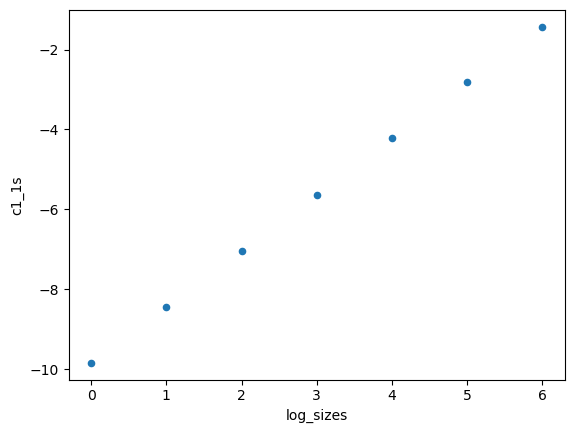

In [92]:
scale_index.plot.scatter('log_sizes', 'c1_1s')

In [93]:
df = scale_index.iloc[1:5]

In [94]:
feature = multifractale_estimation(df)
feature

{'c1_1': 1.405092503183625,
 'c2_1': 0.03762288297633109,
 'c1_2': 1.4605601186645638,
 'c2_2': 0.14780389760544926,
 'rho': 0.6283621182302651}

In [101]:
print(feature['c2_1']**.5, ((feature['c1_1'] - 2*np.log(2))*2)**.5)
print(feature['c2_2']**.5, ((feature['c1_2'] - 2*np.log(2))*2)**.5)

0.19396619029184206 0.19389761248522078
0.38445272479909576 0.3853978659636642


In [96]:
2*np.log(2) + sigma1**2/2

1.4062943611198906

In [152]:
paris = np.load('paris_household.npy')
print(paris.sum(axis=(0,1)))
paris = paris[32:96, 32:96,:]
#paris[paris==0] = 1
paris[:,:,0] = paris[:,:,0] / paris[:,:,0].sum() 
paris[:,:,1] = paris[:,:,1] / paris[:,:,1].sum() 

[ 415654.4 2329657.1]


In [137]:
paris.shape

(64, 64, 2)

C:\Users\francois.semecurbe\AppData\Local\Temp\ipykernel_17872\1739913897.py:1: RuntimeWarning: invalid value encountered in divide
  plt.imshow(paris[:,:,0]/(paris[:,:,0]+paris[:,:,1]) )


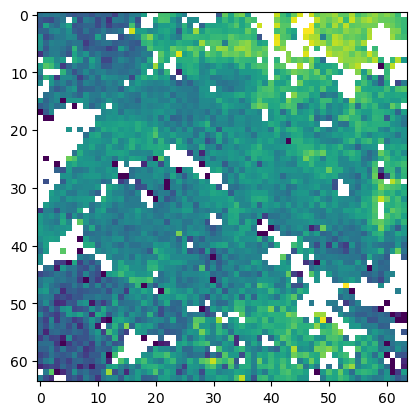

In [165]:
plt.imshow(paris[:,:,0]/(paris[:,:,0]+paris[:,:,1]) )

In [139]:
scale_index = multiscale_estimation(paris)
scale_index

,sizes,log_sizes,c1_1s,c2_1s,c1_2s,c2_2s,rhos
0,1,0.0,-8.724948,1.894181,-8.697052,1.921963,0.885831
1,2,1.0,-7.376976,1.773759,-7.386292,1.980529,0.904983
2,4,2.0,-5.918379,1.506025,-5.886009,1.276549,0.915639
3,8,3.0,-4.357907,0.483292,-4.335466,0.417890,0.809462
4,16,4.0,-2.881556,0.235946,-2.849047,0.159959,0.744384
5,32,5.0,-1.428543,0.078515,-1.390399,0.008027,0.885339


<Axes: xlabel='log_sizes', ylabel='c1_2s'>

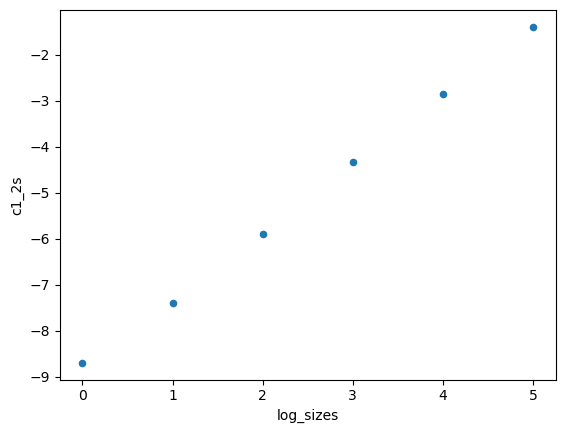

In [164]:
scale_index.plot.scatter('log_sizes', 'c1_2s')

,sizes,log_sizes,c1_1s,c2_1s,c1_2s,c2_2s,rhos
4,16,4.0,-4.536185,0.913454,-4.464685,0.648876,0.832144
5,32,5.0,-3.016669,0.500457,-2.986313,0.407596,0.816332
6,64,6.0,-1.440243,0.105662,-1.386724,0.000868,0.755216


In [169]:
df = scale_index.iloc[2:5]
print(df)
paris_feature = multifractale_estimation(df)
print(paris_feature)

   sizes  log_sizes     c1_1s     c2_1s     c1_2s     c2_2s      rhos
2      4        2.0 -5.918379  1.506025 -5.886009  1.276549  0.915639
3      8        3.0 -4.357907  0.483292 -4.335466  0.417890  0.809462
4     16        4.0 -2.881556  0.235946 -2.849047  0.159959  0.744384
{'c1_1': 1.5184117596796733, 'c2_1': 0.6350392851991362, 'c1_2': 1.5184810421936026, 'c2_2': 0.558294750864895, 'rho': 0.8231615929518906}


In [170]:
print(paris_feature['c2_1']**.5, ((paris_feature['c1_1'] - 2*np.log(2))*2)**.5)
print(paris_feature['c2_2']**.5, ((paris_feature['c1_2'] - 2*np.log(2))*2)**.5)

0.7968935218704793 0.5140377390032423
0.7471912411591125 0.5141725023252643


In [132]:
paris_feature['c2_2']**.5

0.6377520025907668

In [ ]:
2*np.log(2) + sigma1**2/2

#### Autre test

In [432]:
data = np.load('carreaux-200m-met-3035-2021s.npy')


In [433]:
paris = data[:,:,[0,7]] # niveau de vie et individu 
paris = data[:,:,[9,10]] # coll et maison df = scale_index.iloc[5:9]

#paris = data[:,:,[1,2]] # pauv non pauv
#paris[:,:,0] = paris[:,:,0] - paris[:,:,1] #df = scale_index.iloc[3:7]

paris = data[:,:,[23,26]] #jeune et vieux df = scale_index.iloc[5:10]

#paris = data[:,:,[12,14]] #logement 
temp = paris.sum(axis=(0,1))
print(temp, temp[1] / temp[0])

[12341354.7  3569546.1] 0.2892345440812908


In [434]:
paris[:,:,0] = paris[:,:,0] / paris[:,:,0].sum() 
paris[:,:,1] = paris[:,:,1] / paris[:,:,1].sum()

In [435]:
scale_index = multiscale_estimation(paris)
scale_index

,sizes,log_sizes,c1_1s,c2_1s,c1_2s,c2_2s,rhos
0,1,0.0,-15.945428,2.249472,-15.728263,1.978985,0.831506
1,2,1.0,-15.652467,2.842357,-15.421597,2.470994,0.860712
2,4,2.0,-15.055311,3.246987,-14.860851,2.852896,0.883166
3,8,3.0,-13.918342,3.397361,-13.805480,3.032927,0.902494
4,16,4.0,-12.393885,3.068708,-12.304967,2.725795,0.930099
5,32,5.0,-10.785813,2.524292,-10.651915,2.145901,0.947449
6,64,6.0,-9.259903,2.270953,-9.068487,1.837676,0.960335
7,128,7.0,-7.805214,2.358188,-7.591790,1.896633,0.976091
8,256,8.0,-6.530839,3.258875,-6.346853,2.944944,0.986364
9,512,9.0,-5.370864,4.507812,-5.215639,4.115912,0.993518


<Axes: xlabel='log_sizes', ylabel='c2_1s'>

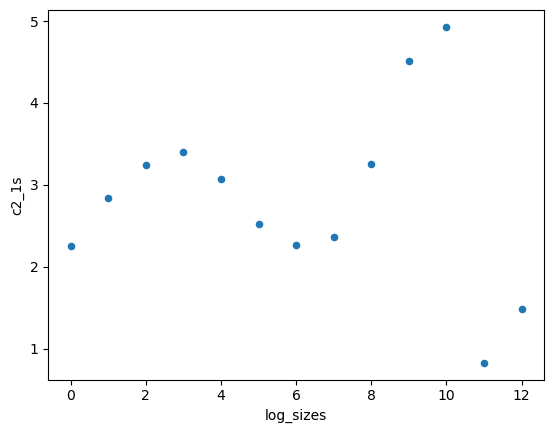

In [437]:
scale_index.plot.scatter('log_sizes', 'c2_1s')

In [430]:
df = scale_index.iloc[5:10]
print(df)
paris_feature = multifractale_estimation(df)
print(paris_feature)

print(paris_feature['c2_1']**.5, ((paris_feature['c1_1'] - 2*np.log(2))*2)**.5)
print(paris_feature['c2_2']**.5, ((paris_feature['c1_2'] - 2*np.log(2))*2)**.5)

   sizes  log_sizes      c1_1s     c2_1s      c1_2s     c2_2s      rhos
5     32        5.0 -10.691015  2.348992 -10.568907  2.033973  0.945657
6     64        6.0  -9.148760  2.120522  -8.963897  1.710989  0.959770
7    128        7.0  -7.647605  2.123060  -7.454701  1.826195  0.973389
8    256        8.0  -6.140891  1.903835  -5.969938  1.721593  0.980624
9    512        9.0  -4.670397  1.232646  -4.538834  1.068090  0.980141
{'c1_1': 1.504910690335587, 'c2_1': 0.24493787938402595, 'c1_2': 1.505410598454361, 'c2_2': 0.19211621497837592, 'rho': 0.9679162824826599}
0.4949119915540802 0.48706535334736456
0.4383106375373246 0.48809064185757656


In [405]:
toto = paris.copy()

In [353]:
toto = block_reduce(toto, block_size = (32,32,1), func = np.sum)

In [354]:
toto.shape

(128, 128, 2)

In [355]:
toto[toto==0]=0.001

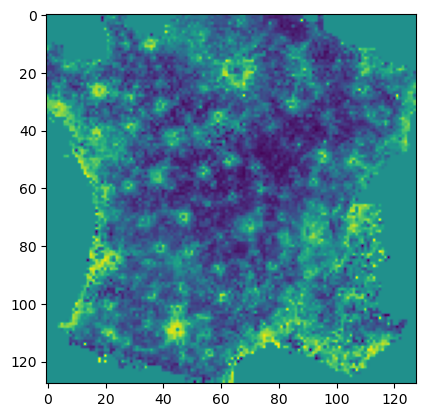

In [356]:
plt.imshow((toto[:,:,1]/(toto[:,:,1]+toto[:,:,0]) ))

C:\Users\francois.semecurbe\AppData\Local\Temp\ipykernel_16968\775635412.py:4: RuntimeWarning: invalid value encountered in divide
  niveau_vie = toto[:, :, 1] / toto[:, :, 0]


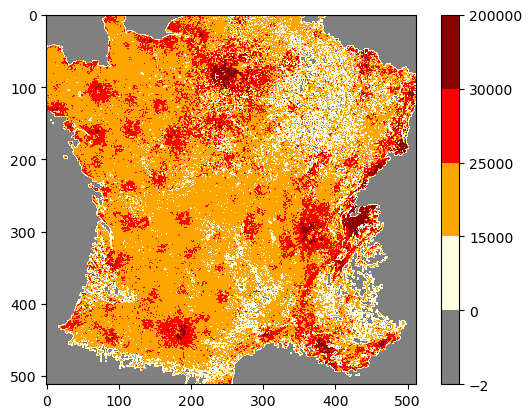

In [224]:
import matplotlib.colors as mcolors
toto = data[:,:,[0,7]]
toto = block_reduce(toto, block_size = (8,8,1), func = np.sum)
niveau_vie = toto[:, :, 1] / toto[:, :, 0]
niveau_vie[~np.isfinite(niveau_vie)] = -1
from matplotlib.colors import ListedColormap, BoundaryNorm
niveau_vie[niveau_vie>100000]=100000
cmap = ListedColormap([
    "gray",
    "lightyellow",
    "orange",
    "red",
    "darkred"
])

bounds = [-2,0, 15000, 25000, 30000, 200000]
norm = BoundaryNorm(bounds, cmap.N)

plt.imshow(niveau_vie, cmap=cmap, norm=norm)
plt.colorbar()
plt.show()

In [73]:
toto.shape

(256, 256, 2)